<a href="https://colab.research.google.com/github/omkargurav-OG/Logistic-Regression/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math


In [ ]:
titanic_data = pd.read_csv('/content/titanic_data.csv')

In [ ]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age
0,1,0,3,"Braund, Mr. Owen Harris",male,22
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38
2,3,1,3,"Heikkinen, Miss. Laina",female,26
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35
4,5,0,3,"Allen, Mr. William Henry",male,35


In [ ]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age
0,1,0,3,"Braund, Mr. Owen Harris",male,22
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38
2,3,1,3,"Heikkinen, Miss. Laina",female,26
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35
4,5,0,3,"Allen, Mr. William Henry",male,35


In [ ]:
pip install PyPDF2

### Extracting Text from PDF using PyPDF2

This code snippet uses the `PyPDF2` library to open the specified PDF file and extract text from each page. The extracted text is then printed to the console.

In [ ]:
import PyPDF2

def extract_text_from_pdf(pdf_path):
    text = ""
    try:
        with open(pdf_path, 'rb') as file:
            reader = PyPDF2.PdfReader(file)
            for page_num in range(len(reader.pages)):
                page = reader.pages[page_num]
                text += page.extract_text()
    except Exception as e:
        text = f"Error extracting text: {e}"
    return text

# Path to your PDF file
pdf_file_path = '/content/titanic_data.pdf'

# Extract text
extracted_pdf_text = extract_text_from_pdf(pdf_file_path)
print(extracted_pdf_text)

In [ ]:
print(str(len(titanic_data.index)))# total no of passengers in orignal data

1783


In [ ]:
print(str(len(titanic_data.index)))# total no of passengers in orignal data

1783


<Axes: xlabel='Survived', ylabel='count'>

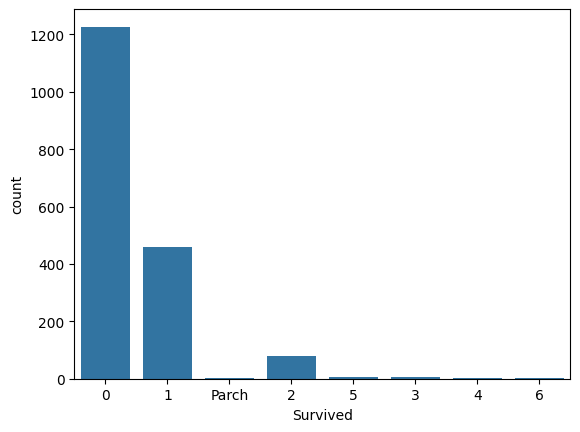

In [ ]:
#knowing how many people survived and died
sns.countplot(x='Survived',data=titanic_data)

<Axes: xlabel='Survived', ylabel='count'>

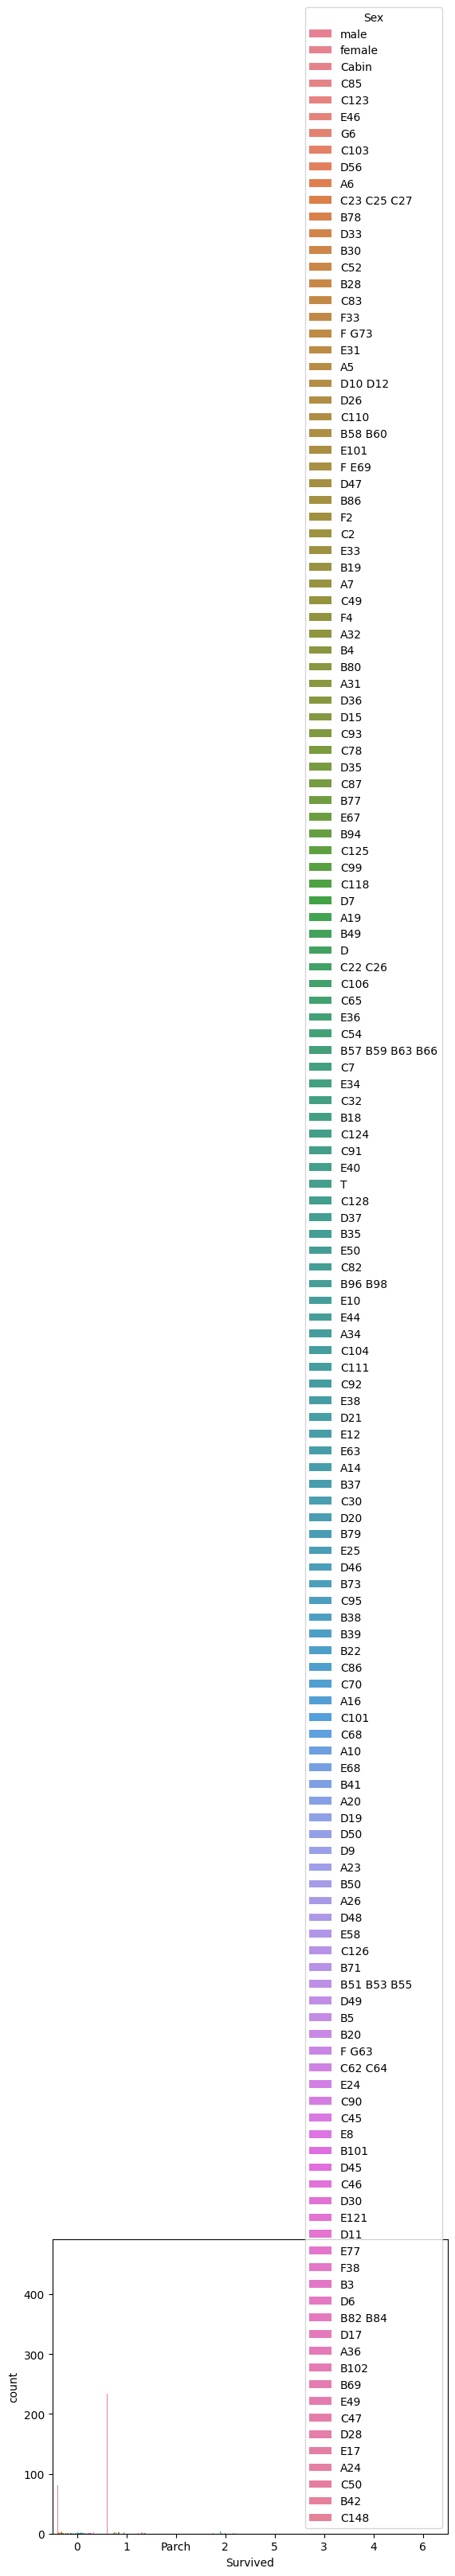

In [ ]:
#knowing howmany male survided and how many females survived
sns.countplot(x='Survived',hue='Sex',data=titanic_data)

<Axes: xlabel='Survived', ylabel='count'>



In [ ]:
#Knowing which class people survived the most
sns.countplot(x='Survived',hue='Pclass',data=titanic_data)

In [ ]:
#Age distribution
titanic_data['Age'].plot.hist()

TypeError: no numeric data to plot

In [ ]:
#fare- the amount of money a passenger paid for their tickit
titanic_data['Fare'].plot.hist(figsize=(8,4))

In [ ]:
titanic_data.info()

In [ ]:
titanic_data.isnull()

In [ ]:
titanic_data.isnull().sum()

In [ ]:
#imputation
titanic_data.drop('Cabin',axis=1,inplace=True)

In [ ]:
titanic_data.head(2)

In [ ]:
titanic_data.dropna(inplace=True)

In [ ]:
titanic_data.isnull().sum()

In [ ]:
titanic_data.head(5)
# we will first convert categorical variables into dummy variabls and then use them as logistic reg only takes 2 inputs

In [ ]:
pd.get_dummies(titanic_data['Sex']).astype(int)


In [ ]:
S = pd.get_dummies(titanic_data['Sex'],drop_first=True).astype(int)
S.head(4)

In [ ]:
#conversion of Embarked column from one form to another
#Q= Quinstown, S=southam , C= chambor
E = pd.get_dummies(titanic_data['Embarked'],drop_first=True).astype(int).astype(int)
E.head(4)

In [ ]:
#conversion of Pclass column from one form to another
P = pd.get_dummies(titanic_data['Pclass'],drop_first=True).astype(int).astype(int)
P.head(4)

In [ ]:
#concatinate all the new rows in the dataset
titanic_data = pd.concat([titanic_data,S,E,P],axis=1)

In [ ]:
titanic_data.head(5)

In [ ]:
titanic_data.drop(['Sex','Embarked','PassengerId','Name','Ticket','Pclass'],axis=1,inplace=True)

In [ ]:
#our final dataset
titanic_data.head(5)

In [ ]:
X = titanic_data.drop('Survived',axis=1)# accept survived all the other columns are indep var
y = titanic_data['Survived']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression()


In [ ]:
X_train.columns = X_train.columns.astype(str)
model.fit(X_train,y_train)


In [ ]:
#X_test.columns = X_test.columns.astype(str)
predictions = model.predict(X_test)

In [ ]:
print("Predictions:")
print(predictions)

In [ ]:
import matplotlib.pyplot as plt

# Assuming you already have your trained model and test data
# model.fit(X_train, y_train)
predictions = model.predict(X_test)

# Plot predicted classes vs the first feature of X_test
plt.plot(X_test.iloc[:, 0], predictions, marker='o', linestyle='-', color='blue')
plt.xlabel('Features')
plt.ylabel('Survived')
plt.title('Logistic Regression Predictions')
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
print(confusion_matrix(y_test,predictions))

In [ ]:
Step 6 : Checking the Accuracy
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test,predictions)